In [102]:
# import requests
import pandas as pd
import numpy as np
from scipy.stats import entropy
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
# from statsmodels.tsa.stattools import adfuller  
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import root_mean_squared_error , mean_absolute_error , mean_absolute_percentage_error          

import itertools

import time
import yaml
pd.options.display.float_format = '{:,.2f}'.format
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

## 1. Data Preparation

In [103]:
df_merged_detrended = pd.read_csv("dataset_FINAL.csv")


In [104]:
df_merged_detrended.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       138 non-null    int64  
 1   date                             138 non-null    object 
 2   Anno                             138 non-null    int64  
 3   Mese                             138 non-null    int64  
 4   GDPGrowth                        138 non-null    float64
 5   WorkingDays                      138 non-null    int64  
 6   fixed_term_diff                  138 non-null    float64
 7   permanent_diff                   138 non-null    float64
 8   workforce_diff                   138 non-null    float64
 9   inactives_diff                   138 non-null    float64
 10  employment_rate_diff             138 non-null    float64
 11  youth_employment_rate_diff       138 non-null    float64
 12  activity_rate_diff    

In [105]:
df_merged_detrended = df_merged_detrended[[ 'date','Anno', 'Mese',  
                                           'GDPGrowth', 'WorkingDays', 'fixed_term_diff',
                                            'permanent_diff', 'workforce_diff', 'inactives_diff',
                                            'employment_rate_diff', 'youth_employment_rate_diff',
                                            'activity_rate_diff', 'unemployment_rate_diff',
                                            'industry_production_prices_diff', 'companies_trust',
                                            'gasoline_car_price_diff', 'diesel_price_diff', 'GPL_price',
                                            'diesel_heatining_price_diff', 'covid_period', 'ukraine_war', 
                                             'rolling_mean_3m', 'rolling_mean_6m',
                                             'rolling_mean_12m', 'rolling_std_12m', 
                                             'lag_1m', 'lag_2m', 'lag_3m', #'lag_12m', 
                                            # 'PCA_labour_market_1', 'PCA_labour_market_2',
                                            # 'PCA_price_energy_1', 'PCA_price_energy_2',
                                            # 'PCA_macroeconomic_variables_1', 'PCA_macroeconomic_variables_2',
                                            'TotSales_diff',  'TotSales'
                                            ]]

In [106]:
X_columns = df_merged_detrended.drop(['TotSales_diff',  'TotSales'], axis = 1)
X_columns.head(4)

,date,Anno,Mese,GDPGrowth,WorkingDays,fixed_term_diff,permanent_diff,workforce_diff,inactives_diff,employment_rate_diff,...,diesel_heatining_price_diff,covid_period,ukraine_war,rolling_mean_3m,rolling_mean_6m,rolling_mean_12m,rolling_std_12m,lag_1m,lag_2m,lag_3m
0,2014-02-01,2014,2,0.19,20,"184,216.00","-40,676.00","157,054.00","-167,294.00",1.12,...,0.01,0,0,"-1,775,113.67","3,716,685.67","850,019.08","13,056,299.26","2,891,512.00","-7,089,094.00","-1,632,360.00"
1,2014-03-01,2014,3,0.14,21,"71,808.00","275,378.00","203,916.00","-214,410.00",0.17,...,-0.01,0,0,"2,606,392.33","1,180,680.50","802,979.50","13,034,620.43","-1,127,759.00","2,891,512.00","-7,089,094.00"
2,2014-04-01,2014,4,0.09,20,"26,839.00","-314,459.00","-420,259.00","410,191.00",-1.24,...,-0.01,0,0,"2,391,750.67","224,218.33","818,156.92","13,036,330.01","6,055,424.00","-1,127,759.00","2,891,512.00"
3,2014-05-01,2014,5,0.06,21,"40,469.00","236,467.00","296,427.00","-307,613.00",2.21,...,0.01,0,0,"4,151,700.67","1,188,293.50","651,172.08","12,974,428.75","2,247,587.00","6,055,424.00","-1,127,759.00"


In [107]:
X_columns['date'] = pd.to_datetime(X_columns['date'])
X_columns = X_columns.set_index('date')
df_merged_detrended['date'] = pd.to_datetime(df_merged_detrended['date'])
df_merged_detrended = df_merged_detrended.set_index('date')

In [108]:
exog_train = X_columns.iloc[5:-12]
exog_test = X_columns.iloc[-12:]

y_train = df_merged_detrended.iloc[5:-12]['TotSales_diff']
y_test = df_merged_detrended.iloc[-12:]['TotSales_diff']

In [143]:
exog_train.columns

Index(['Anno', 'Mese', 'GDPGrowth', 'WorkingDays', 'fixed_term_diff',
       'permanent_diff', 'workforce_diff', 'inactives_diff',
       'employment_rate_diff', 'youth_employment_rate_diff',
       'activity_rate_diff', 'unemployment_rate_diff',
       'industry_production_prices_diff', 'companies_trust',
       'gasoline_car_price_diff', 'diesel_price_diff', 'GPL_price',
       'diesel_heatining_price_diff', 'covid_period', 'ukraine_war',
       'rolling_mean_3m', 'rolling_mean_6m', 'rolling_mean_12m',
       'rolling_std_12m', 'lag_1m', 'lag_2m', 'lag_3m'],
      dtype='object')

In [115]:
start = time.time()
# Define the ranges for p, d, q parameters
p = d = q = range(0, 3)

# Create a list of all possible combinations of p, d, q values
pdq = list(itertools.product(p, d, q))

# Define the seasonal parameter combinations (P, D, Q, s)
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in pdq] 

print(f'Minuti: {(time.time() - start)/60}')

Minuti: 0.0


In [116]:
# Lists to store parameters and AIC values
list_param = []
list_param_seasonal = []
list_results_aic = []

# # Variables to track the best model
best_aic = float("inf")  # Start with an infinitely large AIC value
best_param = None
best_param_seasonal = None

In [ ]:
# Loop over each combination of pdq and seasonal_pdq
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            # Fit the SARIMA model with the specified parameters
            model = SARIMAX(y_train,
                            exog=exog_train, 
                            order=param,
                            seasonal_order=param_seasonal,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            results = model.fit()

            # Save the parameter combination and its AIC
            list_param.append(param)
            list_param_seasonal.append(param_seasonal)
            list_results_aic.append(results.aic)
            
            # Print the current combination and its AIC
            print('ARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic))
            
            # Update the best model if the current one has a lower AIC
            if results.aic < best_aic:
                best_aic = results.aic
                best_param = param
                best_param_seasonal = param_seasonal
        except:
            # If the model fails to fit, skip this combination
            continue

In [118]:
# Print the best model parameters
print("\nBest Model:")
print('ARIMA{}x{}12 - AIC:{}'.format(best_param, best_param_seasonal, best_aic))


Best Model:
ARIMANonexNone12 - AIC:inf


## 2. Model: SARIMAX

In [144]:
best_param = (1, 1, 0)
best_param_seasonal = (0, 1, 0, 12)

In [145]:
model = SARIMAX(y_train,
                exog=exog_train, 
                order=best_param,
                seasonal_order=best_param_seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit()


h = 12  # forecast horizon

# Training
exog_train_pred = exog_train.iloc[-h:]  # 121 months
 

forecast_res = results.get_forecast(
    steps=h,
    exog=exog_train_pred              # required if you used exog
)

forecast_mean = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05)  # 95% CI

In [146]:
forecast_res.predicted_mean

2024-08-01   -43,692,789.00
2024-09-01    33,398,476.00
2024-10-01    11,298,305.00
2024-11-01    15,440,126.00
2024-12-01   -20,125,034.00
2025-01-01    -9,409,784.00
2025-02-01    -6,770,765.00
2025-03-01     3,773,112.00
2025-04-01    11,489,534.00
2025-05-01     7,646,524.00
2025-06-01       506,628.00
2025-07-01     4,913,089.00
Freq: MS, Name: predicted_mean, dtype: float64

### Testing

In [136]:
results.predict(start=exog_test.index[0], end=exog_test.index[-1], exog=exog_test, dynamic=True)

2024-08-01   -58,841,134.00
2024-09-01    37,715,029.00
2024-10-01    16,989,872.00
2024-11-01     3,383,423.00
2024-12-01    -8,128,612.00
2025-01-01   -15,403,902.00
2025-02-01   -14,843,127.00
2025-03-01    14,287,146.00
2025-04-01     6,510,598.00
2025-05-01     1,146,047.00
2025-06-01     5,905,147.00
2025-07-01    12,050,889.00
Freq: MS, Name: predicted_mean, dtype: float64

In [137]:
y_test

date
2024-08-01   -58,841,134.00
2024-09-01    37,715,029.00
2024-10-01    16,989,872.00
2024-11-01     3,383,423.00
2024-12-01    -8,128,612.00
2025-01-01   -15,403,902.00
2025-02-01   -14,843,127.00
2025-03-01    14,287,146.00
2025-04-01     6,510,598.00
2025-05-01     1,146,047.00
2025-06-01     5,905,147.00
2025-07-01    12,050,889.00
Name: TotSales_diff, dtype: float64

In [126]:
h = 12  # forecast horizon

forecast_res_test = results.get_forecast(
    steps=h,
    exog=exog_test              # required if you used exog
)

forecast_mean_test = forecast_res_test.predicted_mean
conf_int = forecast_res_test.conf_int(alpha=0.05)  # 95% CI

In [127]:
y_original = df_merged_detrended['TotSales'].iloc[-13] 

In [128]:
# Reversing the difference:
anchor =  df_merged_detrended['TotSales'].iloc[-13] 
final_forecast = forecast_mean_test.cumsum() + anchor

In [129]:
final_forecast

2024-08-01   164,277,121.00
2024-09-01   201,992,150.00
2024-10-01   218,982,022.00
2024-11-01   222,365,445.00
2024-12-01   214,236,833.00
2025-01-01   198,832,931.00
2025-02-01   183,989,804.00
2025-03-01   198,276,950.00
2025-04-01   204,787,548.00
2025-05-01   205,933,595.00
2025-06-01   211,838,742.00
2025-07-01   223,889,631.00
Freq: MS, Name: predicted_mean, dtype: float64

In [130]:
forecast_mean_test

2024-08-01   -58,841,134.00
2024-09-01    37,715,029.00
2024-10-01    16,989,872.00
2024-11-01     3,383,423.00
2024-12-01    -8,128,612.00
2025-01-01   -15,403,902.00
2025-02-01   -14,843,127.00
2025-03-01    14,287,146.00
2025-04-01     6,510,598.00
2025-05-01     1,146,047.00
2025-06-01     5,905,147.00
2025-07-01    12,050,889.00
Freq: MS, Name: predicted_mean, dtype: float64

In [131]:
y_test

date
2024-08-01   -58,841,134.00
2024-09-01    37,715,029.00
2024-10-01    16,989,872.00
2024-11-01     3,383,423.00
2024-12-01    -8,128,612.00
2025-01-01   -15,403,902.00
2025-02-01   -14,843,127.00
2025-03-01    14,287,146.00
2025-04-01     6,510,598.00
2025-05-01     1,146,047.00
2025-06-01     5,905,147.00
2025-07-01    12,050,889.00
Name: TotSales_diff, dtype: float64

In [132]:
df_merged_detrended['TotSales'].tail(12) 

date
2024-08-01    164277121
2024-09-01    201992150
2024-10-01    218982022
2024-11-01    222365445
2024-12-01    214236833
2025-01-01    198832931
2025-02-01    183989804
2025-03-01    198276950
2025-04-01    204787548
2025-05-01    205933595
2025-06-01    211838742
2025-07-01    223889631
Name: TotSales, dtype: int64

In [13]:
print("------------------ NO PCA VARIABLES -------------------------")
print(f"RMSE train: {root_mean_squared_error(y_train.iloc[-h:], forecast_mean)}"), 
print(f"RMSE test : {root_mean_squared_error(y_test, forecast_mean_test)}")
                                        

------------------ NO PCA VARIABLES -------------------------
RMSE train: 1.5913824041627313e-07
RMSE test : 1.444093785619072e-07


In [14]:
print("------------------ NO PCA VARIABLES -------------------------")
print(f"MAE train: {mean_absolute_error(y_train.iloc[-h:], forecast_mean)}"), 
print(f"MAE test : {mean_absolute_error(y_test, forecast_mean_test)}")


------------------ NO PCA VARIABLES -------------------------
MAE train: 1.1593025798598926e-07
MAE test : 1.0240667810042699e-07


In [15]:
print("------------------ NO PCA VARIABLES -------------------------")
print(f"MAPE train: {mean_absolute_percentage_error(y_train.iloc[-h:], forecast_mean)}"), 
print(f"MAPE test : {mean_absolute_percentage_error(y_test, forecast_mean_test)}")
     

------------------ NO PCA VARIABLES -------------------------
MAPE train: 9.156186221016013e-15
MAPE test : 1.0104525622615528e-14


In [16]:
# print("-----------------------ALL VARIABLES-------------------------")
# print(f"RMSE train: {root_mean_squared_error(y_train.iloc[-h:], forecast_mean)}"), 
# print(f"RMSE test : {root_mean_squared_error(y_test, forecast_mean_test)}")
                                        

### Plotting results

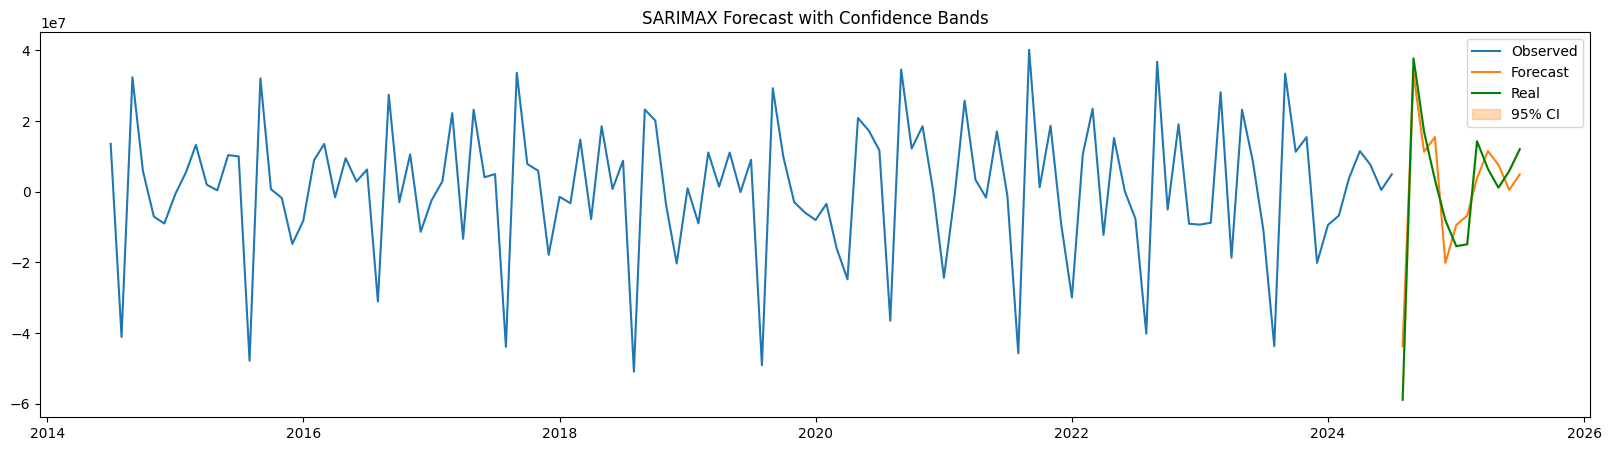

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

plt.plot(y_train.index, y_train, label='Observed')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='C1')
plt.plot(y_test.index, y_test, label='Real', color = 'green')

plt.fill_between(
    forecast_mean.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='C1',
    alpha=0.3,
    label='95% CI'
)

plt.legend()
plt.title("SARIMAX Forecast with Confidence Bands")
plt.show()


# Back Up

## plot 2 

In [50]:
# forecast_mean_test = forecast_res_test.predicted_mean
forecast_res_test.conf_int(alpha=0.05)

,lower TotSales_diff,upper TotSales_diff
2024-08-01,"-58,841,134.00","-58,841,134.00"
2024-09-01,"37,715,029.00","37,715,029.00"
2024-10-01,"16,989,872.00","16,989,872.00"
2024-11-01,"3,383,423.00","3,383,423.00"
2024-12-01,"-8,128,612.00","-8,128,612.00"
2025-01-01,"-15,403,902.00","-15,403,902.00"
2025-02-01,"-14,843,127.00","-14,843,127.00"
2025-03-01,"14,287,146.00","14,287,146.00"
2025-04-01,"6,510,598.00","6,510,598.00"
2025-05-01,"1,146,047.00","1,146,047.00"


In [ ]:
forecast_mean_test = forecast_res_test.predicted_mean
# conf_int = forecast_res_test.conf_int(alpha=0.05)

,lower TotSales_diff,upper TotSales_diff
2024-08-01,"-58,841,134.00","-58,841,134.00"
2024-09-01,"37,715,029.00","37,715,029.00"
2024-10-01,"16,989,872.00","16,989,872.00"
2024-11-01,"3,383,423.00","3,383,423.00"
2024-12-01,"-8,128,612.00","-8,128,612.00"
2025-01-01,"-15,403,902.00","-15,403,902.00"
2025-02-01,"-14,843,127.00","-14,843,127.00"
2025-03-01,"14,287,146.00","14,287,146.00"
2025-04-01,"6,510,598.00","6,510,598.00"
2025-05-01,"1,146,047.00","1,146,047.00"


In [28]:
y

2024-08-01   -58,841,134.00
2024-09-01    37,715,029.00
2024-10-01    16,989,872.00
2024-11-01     3,383,423.00
2024-12-01    -8,128,612.00
2025-01-01   -15,403,902.00
2025-02-01   -14,843,127.00
2025-03-01    14,287,146.00
2025-04-01     6,510,598.00
2025-05-01     1,146,047.00
2025-06-01     5,905,147.00
2025-07-01    12,050,889.00
Freq: MS, Name: predicted_mean, dtype: float64

In [ ]:
import scipy.stats as stats

y = forecast_res_test.predicted_mean

# Calculate mean and standard error
mean = np.mean(y)
se = stats.sem(y)

# Calculate 95% confidence interval
ci = stats.t.interval(alpha=0.95, 
                      df
                      #df=len(y)-1, 
                      loc=mean, 
                      scale=se)

print(f"Sample mean: {mean:.2f}")
print(f"95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})")

TypeError: rv_generic.interval() missing 1 required positional argument: 'confidence'

## Uncertainty Coefficient

In [ ]:
def _validate_and_crosstab(x, y):
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    if df.empty:
        return None
    pxy_table = pd.crosstab(df["x"], df["y"], normalize='all')
    if pxy_table.size == 0 or pxy_table.values.sum() == 0:
        return None
    return pxy_table.to_numpy(dtype=float)
 
def uncertainty_coefficients(x,y,base = 2):
    """Compute Theil's U between two categorical variables.
   
    Params
    ------
    x, y: array-like (categorical, string, or discrete)
          Variables of equal length. NaN pairs are dropped pairwise.
    base: float, optional (default = 2)
          Logarithm base for the entropy.
         
    Returns
    -------
    dict with keys:
        - 'U_X_given_Y' : U(X | Y) = I(X;Y) / H(X)
        - 'U_Y_given_X' : U(Y | X) = I(X;Y) / H(Y)
        - 'U_symmetric' : 2 * I(X;Y) / (H(X) + H(Y))   (0 if both entropies are 0)
 
    Notes
    -----
    I(X;Y) = H(X) + H(Y) - H(X,Y)
    H(X|Y) = H(X,Y) - H(Y)
    When H(X)=0 (or H(Y)=0), the corresponding asymmetric U is defined as 0.0.
    """
    pxy = _validate_and_crosstab(x, y)
    if pxy is None:
        return {"U_X_given_Y": np.nan, "U_Y_given_X": np.nan, "U_symmetric": np.nan}
   
    px = pxy.sum(axis = 1)
    py = pxy.sum(axis = 0)
   
    Hx = entropy(px, base=base)
    Hy = entropy(py, base=base)
    Hxy = entropy(pxy.ravel(), base=base)
   
    Ixy = Hx + Hy - Hxy
   
    U_x_given_y = 0.0 if np.isclose(Hx,0.0) else Ixy / Hx
    U_y_given_x = 0.0 if np.isclose(Hy,0.0) else Ixy / Hy
   
    den = Hx + Hy
    U_sym = 0.0 if np.isclose(den, 0.0) else (2.0 * Ixy) / den
   
    return {"U_X_given_Y": U_x_given_y, "U_Y_given_X": U_y_given_x, "U_symmetric": U_sym}
 
def pairwise_uncertainty(df, cols = None, base=2, symmetric=False):
    """Compute a pairwise matrix of Theil's uncertainty coefficients for a DataFrame.
   
    Params
    ------
        df: pandas.DataFrame
            The data. Non-categorical columns are allowed.
        cols: list-like or None
              Subset of cols to include. Defaults to all columns.
        base: float
              Entropy base (2 for bits)
        symmetric: bool
                   If True, returns the symmetric coefficient, else returns
                   U(X|Y) with rows = X, cols = Y.
   
    Returns
    -------
    pandas.DataFrame
        Matrix of uncertainty coeffs.
    """
    if cols is None:
        cols = list(df.columns)
   
    cols = list(cols)
    res = pd.DataFrame(index=cols, columns=cols, dtype=float)
   
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if i == j:
                res.iloc[i,j] = 1
                continue
            coeffs = uncertainty_coefficients(df[c1], df[c2], base=base)
            res.iloc[i,j] = coeffs["U_symmetric"] if symmetric else coeffs["U_X_given_Y"]
   
    return res
 

In [ ]:
df_train['y_train_pred'] = forecast_res_test.predicted_mean

,Anno,Mese,GDPGrowth,WorkingDays,fixed_term_diff,permanent_diff,workforce_diff,inactives_diff,employment_rate_diff,youth_employment_rate_diff,...,lag_1m,lag_2m,lag_3m,PCA_labour_market_1,PCA_labour_market_2,PCA_price_energy_1,PCA_price_energy_2,PCA_macroeconomic_variables_1,PCA_macroeconomic_variables_2,TotSales_diff
date,,,,,,,,,,,,,,,,,,,,,
2014-07-01,2014,7,0.05,23,"-27,097.00","-124,865.00","89,370.00","-118,289.00",0.40,-0.15,...,"358,018.00","4,152,091.00","2,247,587.00",0.48,0.75,0.05,0.07,-3.05,0.57,"13,553,773.00"
2014-08-01,2014,8,0.04,20,"-124,609.00","-47,652.00","-516,487.00","500,959.00",-0.42,-0.56,...,"13,553,773.00","358,018.00","4,152,091.00",-3.88,-0.30,0.03,0.08,-6.03,2.01,"-41,080,549.00"
2014-09-01,2014,9,0.04,22,"55,403.00","238,811.00","660,930.00","-675,845.00",-0.58,0.45,...,"-41,080,549.00","13,553,773.00","358,018.00",4.51,2.26,0.02,0.08,-8.12,2.97,"32,368,125.00"
2014-10-01,2014,10,0.04,23,"9,818.00","-124,981.00","405,841.00","-422,532.00",0.59,0.34,...,"32,368,125.00","-41,080,549.00","13,553,773.00",2.70,0.86,-0.01,0.08,-8.50,3.08,"5,855,851.00"
2014-11-01,2014,11,0.04,20,"-26,668.00","-174,220.00","-64,787.00","50,367.00",-0.54,-0.68,...,"5,855,851.00","32,368,125.00","-41,080,549.00",-0.99,1.53,-0.04,0.07,-8.67,3.18,"-7,007,504.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-01,2024,3,0.65,21,"201,817.00","-53,261.00","56,888.00","-37,775.00",1.06,0.57,...,"-6,770,765.00","-9,409,784.00","-20,125,034.00",0.85,-2.06,0.01,0.04,2.01,-1.12,"3,773,112.00"
2024-04-01,2024,4,0.70,22,"-72,549.00","288,747.00","-34,052.00","57,153.00",-1.48,0.24,...,"3,773,112.00","-6,770,765.00","-9,409,784.00",-0.56,0.54,0.04,0.02,1.17,-0.86,"11,489,534.00"
2024-05-01,2024,5,0.66,23,"144,853.00","-165,434.00","-130,253.00","149,366.00",0.95,-0.11,...,"11,489,534.00","3,773,112.00","-6,770,765.00",-0.77,-1.35,-0.06,0.07,0.41,-0.24,"7,646,524.00"


In [ ]:
x = exog_train
y = 
uncertainty_coefficients(x,y,base = 2)

In [ ]:
df_unc_corr = pairwise_uncertainty(df_to_corr)
df_unc_corr

In [24]:
for x_col in exog_train.columns:
    print(exog_train[x_col])

date
2014-07-01   0.05
2014-08-01   0.04
2014-09-01   0.04
2014-10-01   0.04
2014-11-01   0.04
             ... 
2024-03-01   0.65
2024-04-01   0.70
2024-05-01   0.66
2024-06-01   0.56
2024-07-01   0.50
Name: GDPGrowth, Length: 121, dtype: float64
date
2014-07-01    23
2014-08-01    20
2014-09-01    22
2014-10-01    23
2014-11-01    20
              ..
2024-03-01    21
2024-04-01    22
2024-05-01    23
2024-06-01    21
2024-07-01    23
Name: WorkingDays, Length: 121, dtype: int64
date
2014-07-01    -27,097.00
2014-08-01   -124,609.00
2014-09-01     55,403.00
2014-10-01      9,818.00
2014-11-01    -26,668.00
                 ...    
2024-03-01    201,817.00
2024-04-01    -72,549.00
2024-05-01    144,853.00
2024-06-01     45,009.00
2024-07-01   -154,587.00
Name: fixed_term_diff, Length: 121, dtype: float64
date
2014-07-01   -124,865.00
2014-08-01    -47,652.00
2014-09-01    238,811.00
2014-10-01   -124,981.00
2014-11-01   -174,220.00
                 ...    
2024-03-01    -53,261.00
2024

In [ ]:
df_train = df_merged_detrended.iloc[:-12]
df_test = df_merged_detrended.iloc[-12:]

In [ ]:
forecast_index = pd.date_range(start='2024-08-01', periods=12)
forecast_data = pd.DataFrame(forecast, index=forecast_index, columns=df_train.columns)

,month
2024-08-31,7
2024-09-30,8
2024-10-31,9
2024-11-30,10
2024-12-31,11
2025-01-31,12
2025-02-28,1
2025-03-31,2
2025-04-30,3
2025-05-31,4


In [ ]:
def sarimax_forecast(SARIMAX_model, periods=24):
    # Forecast
    n_periods = periods

    forecast_df = pd.DataFrame({"month": pd.date_range(df_train.index[-1], periods=n_periods, freq='M').month},
                               index=pd.date_range(df_train.index[-1] + pd.DateOffset(months=1), 
                                periods=n_periods, freq='M'))

    fitted, confint = SARIMAX_model.predict(n_periods=n_periods,
                                            return_conf_int=True,
                                            exogenous=forecast_df[['month_index']])
    index_of_fc = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=n_periods, freq='MS')

    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=index_of_fc)
    lower_series = pd.Series(confint[:, 0], index=index_of_fc)
    upper_series = pd.Series(confint[:, 1], index=index_of_fc)

    # # Plot
    # plt.figure(figsize=(15, 7))
    # plt.plot(df[&quot;#Passengers&quot;], color='#1f76b4')
    # plt.plot(fitted_series, color='darkgreen')
    # plt.fill_between(lower_series.index,
    #                  lower_series,
    #                  upper_series,
    #                  color='k', alpha=.15)

    # plt.title(&quot;SARIMAX - Forecast of Airline Passengers&quot;)
    # plt.show()

## 3. Saving the models and parameters

In [ ]:
var_dict = {
"lags" : results.k_ar
,"variables": results.names
,"params" : results.params.to_dict()
# ,"sigma_u" : results.sigma_u.tolist()
#  ,"aic" : results.aic
#  ,"bic" : results.bic
}

In [ ]:
from pathlib import Path
 
BASE_DIR = Path.cwd()   # current working directory
CONFIG_PATH = BASE_DIR / "configs" 

with open(CONFIG_PATH / "SARIMAX_baseline.yaml", "w") as f:
    yaml.safe_dump(var_dict)

In [ ]:
import pickle

BASE_DIR = Path.cwd()   # current working directory
PATH = BASE_DIR / "models" 

with open(PATH / "SARIMAX_model.pkl", "wb") as f:
    pickle.dump(results, f)

# BACK UP

## 1.2 Correlation

In [12]:
def _validate_and_crosstab(x, y):
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    if df.empty:
        return None
    pxy_table = pd.crosstab(df["x"], df["y"], normalize='all')
    if pxy_table.size == 0 or pxy_table.values.sum() == 0:
        return None
    return pxy_table.to_numpy(dtype=float)
 
def uncertainty_coefficients(x,y,base = 2):
    """Compute Theil's U between two categorical variables.
   
    Params
    ------
    x, y: array-like (categorical, string, or discrete)
          Variables of equal length. NaN pairs are dropped pairwise.
    base: float, optional (default = 2)
          Logarithm base for the entropy.
         
    Returns
    -------
    dict with keys:
        - 'U_X_given_Y' : U(X | Y) = I(X;Y) / H(X)
        - 'U_Y_given_X' : U(Y | X) = I(X;Y) / H(Y)
        - 'U_symmetric' : 2 * I(X;Y) / (H(X) + H(Y))   (0 if both entropies are 0)
 
    Notes
    -----
    I(X;Y) = H(X) + H(Y) - H(X,Y)
    H(X|Y) = H(X,Y) - H(Y)
    When H(X)=0 (or H(Y)=0), the corresponding asymmetric U is defined as 0.0.
    """
    pxy = _validate_and_crosstab(x, y)
    if pxy is None:
        return {"U_X_given_Y": np.nan, "U_Y_given_X": np.nan, "U_symmetric": np.nan}
   
    px = pxy.sum(axis = 1)
    py = pxy.sum(axis = 0)
   
    Hx = entropy(px, base=base)
    Hy = entropy(py, base=base)
    Hxy = entropy(pxy.ravel(), base=base)
   
    Ixy = Hx + Hy - Hxy
   
    U_x_given_y = 0.0 if np.isclose(Hx,0.0) else Ixy / Hx
    U_y_given_x = 0.0 if np.isclose(Hy,0.0) else Ixy / Hy
   
    den = Hx + Hy
    U_sym = 0.0 if np.isclose(den, 0.0) else (2.0 * Ixy) / den
   
    return {"U_X_given_Y": U_x_given_y, "U_Y_given_X": U_y_given_x, "U_symmetric": U_sym}
 
def pairwise_uncertainty(df, cols = None, base=2, symmetric=False):
    """Compute a pairwise matrix of Theil's uncertainty coefficients for a DataFrame.
   
    Params
    ------
        df: pandas.DataFrame
            The data. Non-categorical columns are allowed.
        cols: list-like or None
              Subset of cols to include. Defaults to all columns.
        base: float
              Entropy base (2 for bits)
        symmetric: bool
                   If True, returns the symmetric coefficient, else returns
                   U(X|Y) with rows = X, cols = Y.
   
    Returns
    -------
    pandas.DataFrame
        Matrix of uncertainty coeffs.
    """
    if cols is None:
        cols = list(df.columns)
   
    cols = list(cols)
    res = pd.DataFrame(index=cols, columns=cols, dtype=float)
   
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if i == j:
                res.iloc[i,j] = 1
                continue
            coeffs = uncertainty_coefficients(df[c1], df[c2], base=base)
            res.iloc[i,j] = coeffs["U_symmetric"] if symmetric else coeffs["U_X_given_Y"]
   
    return res
 

In [13]:
df_unc_corr = pairwise_uncertainty(df_to_corr)
df_unc_corr

,Anno,Mese,GDPGrowth,WorkingDays,fixed_term,permanent,workforce,inactives,employment_rate,youth_employment_rate,...,unemployment_rate,industry_production_prices,companies_trust,gasoline_car_price,diesel_price,GPL_price,diesel_heatining_price,TotSales,covid_period,ukraine_war
Anno,1.000000,0.009469,0.972160,0.087370,1.0,1.0,1.0,1.0,0.967691,0.982050,...,0.962746,0.902417,0.856553,1.0,1.0,0.996410,1.0,1.0,0.091439,0.214660
Mese,0.009748,1.000000,0.971340,0.183446,1.0,1.0,1.0,1.0,0.951955,0.977825,...,0.954256,0.809680,0.798838,1.0,1.0,0.996304,1.0,1.0,0.002164,0.001050
GDPGrowth,0.503588,0.488756,1.000000,0.295430,1.0,1.0,1.0,1.0,0.972106,0.988842,...,0.973263,0.902376,0.893009,1.0,1.0,0.998140,1.0,1.0,0.065552,0.113325
WorkingDays,0.146947,0.299703,0.959215,1.000000,1.0,1.0,1.0,1.0,0.939621,0.975848,...,0.931304,0.787953,0.745924,1.0,1.0,0.993962,1.0,1.0,0.005431,0.030604
fixed_term,0.509710,0.495116,0.983980,0.303057,1.0,1.0,1.0,1.0,0.972553,0.989021,...,0.973692,0.903940,0.894737,1.0,1.0,0.998170,1.0,1.0,0.064502,0.116551
permanent,0.509710,0.495116,0.983980,0.303057,1.0,1.0,1.0,1.0,0.972553,0.989021,...,0.973692,0.903940,0.894737,1.0,1.0,0.998170,1.0,1.0,0.064502,0.116551
workforce,0.509710,0.495116,0.983980,0.303057,1.0,1.0,1.0,1.0,0.972553,0.989021,...,0.973692,0.903940,0.894737,1.0,1.0,0.998170,1.0,1.0,0.064502,0.116551
inactives,0.509710,0.495116,0.983980,0.303057,1.0,1.0,1.0,1.0,0.972553,0.989021,...,0.973692,0.903940,0.894737,1.0,1.0,0.998170,1.0,1.0,0.064502,0.116551
employment_rate,0.507162,0.484630,0.983528,0.292795,1.0,1.0,1.0,1.0,1.000000,0.988711,...,0.972949,0.903110,0.891742,1.0,1.0,0.998119,1.0,1.0,0.060678,0.119840
youth_employment_rate,0.506118,0.489511,0.983802,0.299021,1.0,1.0,1.0,1.0,0.972248,1.000000,...,0.973400,0.902873,0.893559,1.0,1.0,0.998150,1.0,1.0,0.065218,0.117845


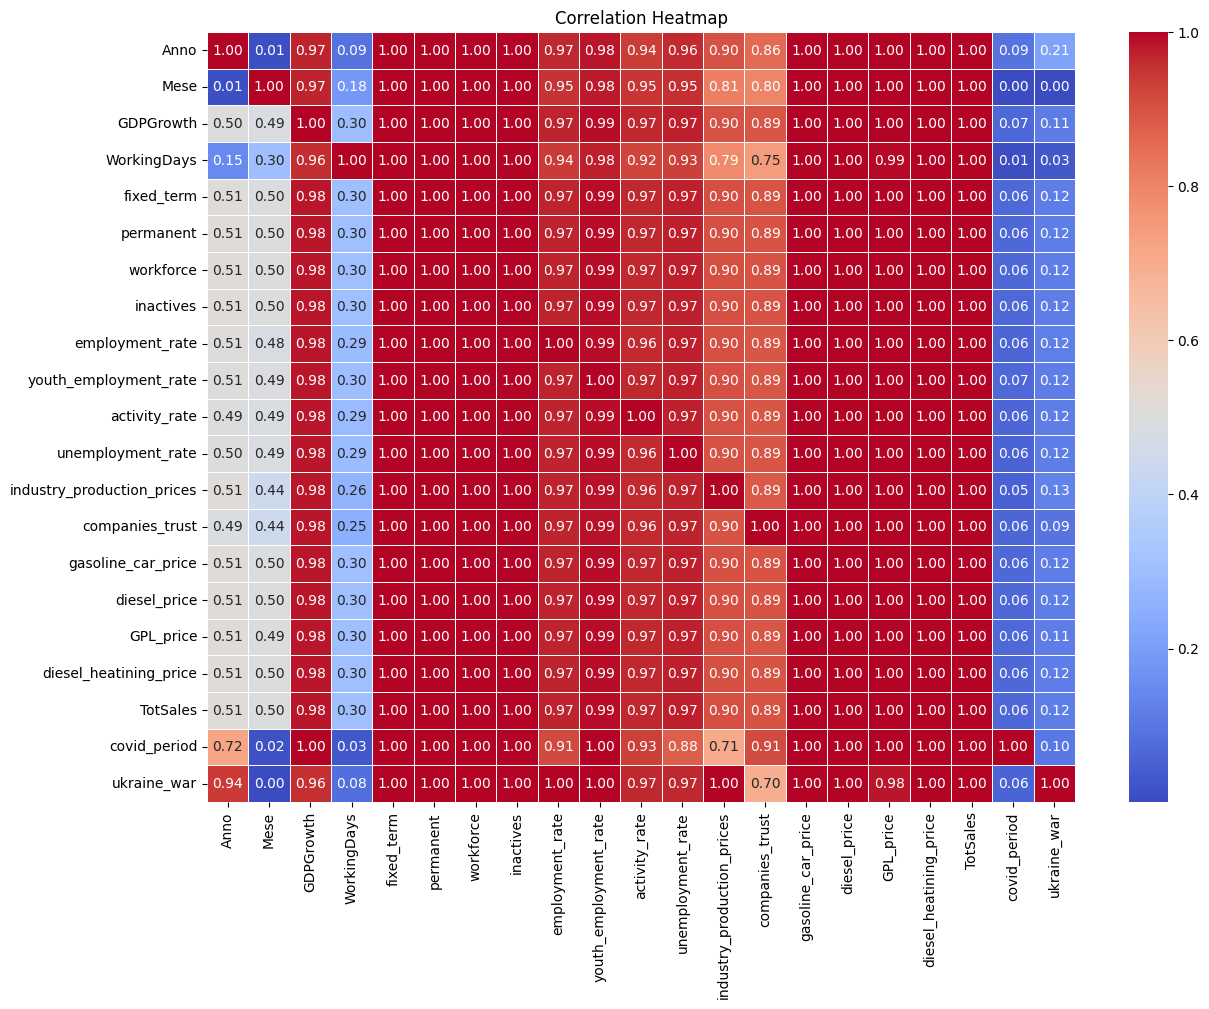

In [15]:

plt.figure(figsize=(14,10))
sns.heatmap(df_unc_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Cose da fare: 

- PCA per le variabili tra loro correlate (es. youth_unemployment e unemployment rate; i vari prezzi dei carburanti)

- selezionare le variabili che sono più correlate rispetto a TotSales (coeff. corr >= 0.40)

- successivamente dovrai fare un po' div ariabili rolling, decomposizione, individuare quali variabili sono stazionarie 

- bisognare predirre le variabili dei mesi futuri usando degli arima --> vedi appunti Tony
